In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:

# Load the CSVs
# df1 = pd.read_csv("./data/device__2__3.csv", parse_dates=["Date"])
# df2 = pd.read_csv("./data/device__8__3.csv ", parse_dates=["Date"])CSVs
df1 = pd.read_csv("./data/dayData_90242_3_experiment.csv", parse_dates=["Date"])
df2 = pd.read_csv("./data/dayData_90248_3_experiment.csv ", parse_dates=["Date"])

In [13]:
df1

,Steps,Activity Score,Zone 3 (Sport),Zone 2 (Health),Zone 1 (Living)
Date,,,,,
2025-05-23,0,0,0,0,0
2025-05-24,0,0,0,0,0
2025-05-25,0,0,0,0,0
2025-05-26,0,0,0,0,0
2025-05-27,0,0,0,0,0
2025-05-28,0,0,0,0,0
2025-05-29,12074,1241,0,290,3
2025-05-30,4397,482,0,111,12
2025-05-31,1245,156,2,27,0


In [12]:
# Align dataframes on date to ensure matching rows
df1.set_index("Date", inplace=True)
df2.set_index("Date", inplace=True)

# Compute the difference
diff = df2 - df1

# Plot settings
metrics = ["Steps", "Activity Score", "Zone 3 (Sport)", "Zone 2 (Health)", "Zone 1 (Living)"]
x = range(len(df1))
metrics

KeyError: "None of ['Date'] are in the columns"

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (10, 5).

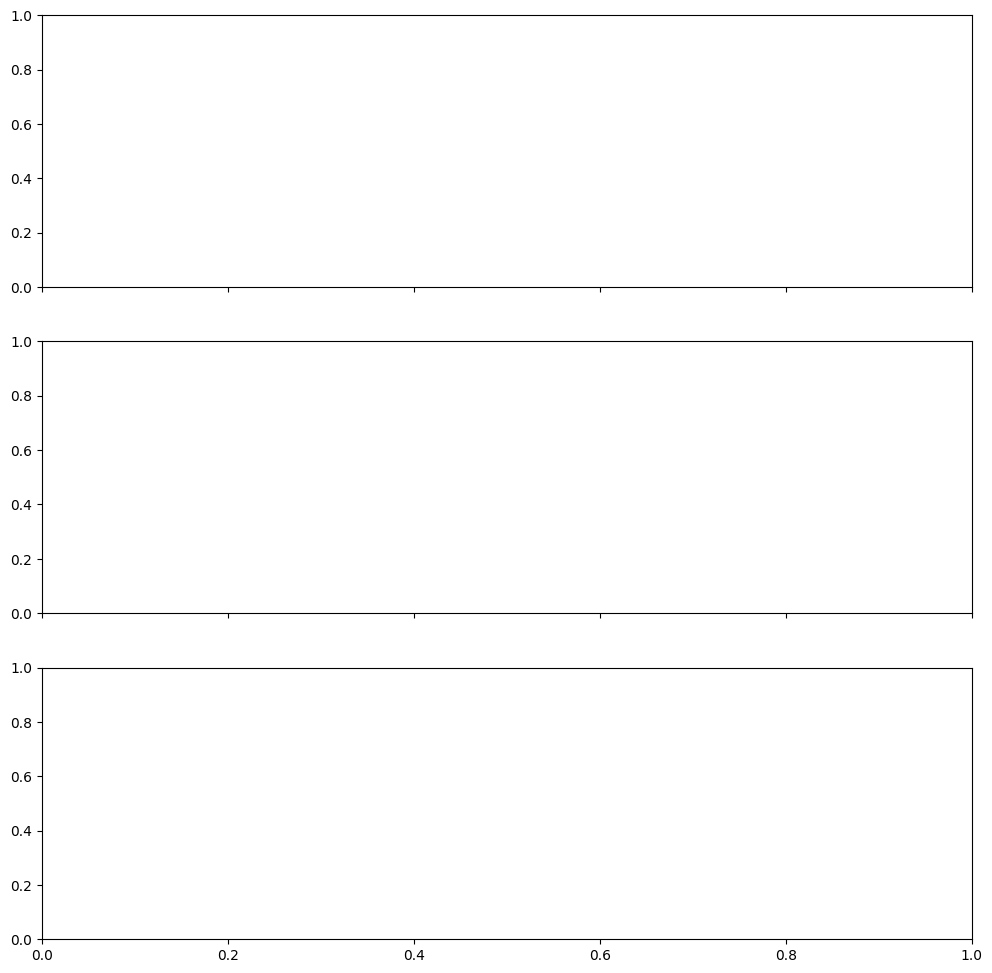

In [11]:





# Plot side-by-side histograms
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12), sharex=True)

# First plot: data1
axes[0].bar(x, df1[metrics].values, label=metrics)
axes[0].set_title("Dataset 1")
axes[0].legend(metrics)

# Second plot: data2
axes[1].bar(x, df2[metrics].values, label=metrics)
axes[1].set_title("Dataset 2")
axes[1].legend(metrics)

# Third plot: difference
axes[2].bar(x, diff[metrics].values, label=metrics)
axes[2].set_title("Difference (Dataset 2 - Dataset 1)")
axes[2].legend(metrics)

# Common settings
plt.xticks(ticks=x, labels=df1.index.date, rotation=45)
plt.tight_layout()
plt.show()


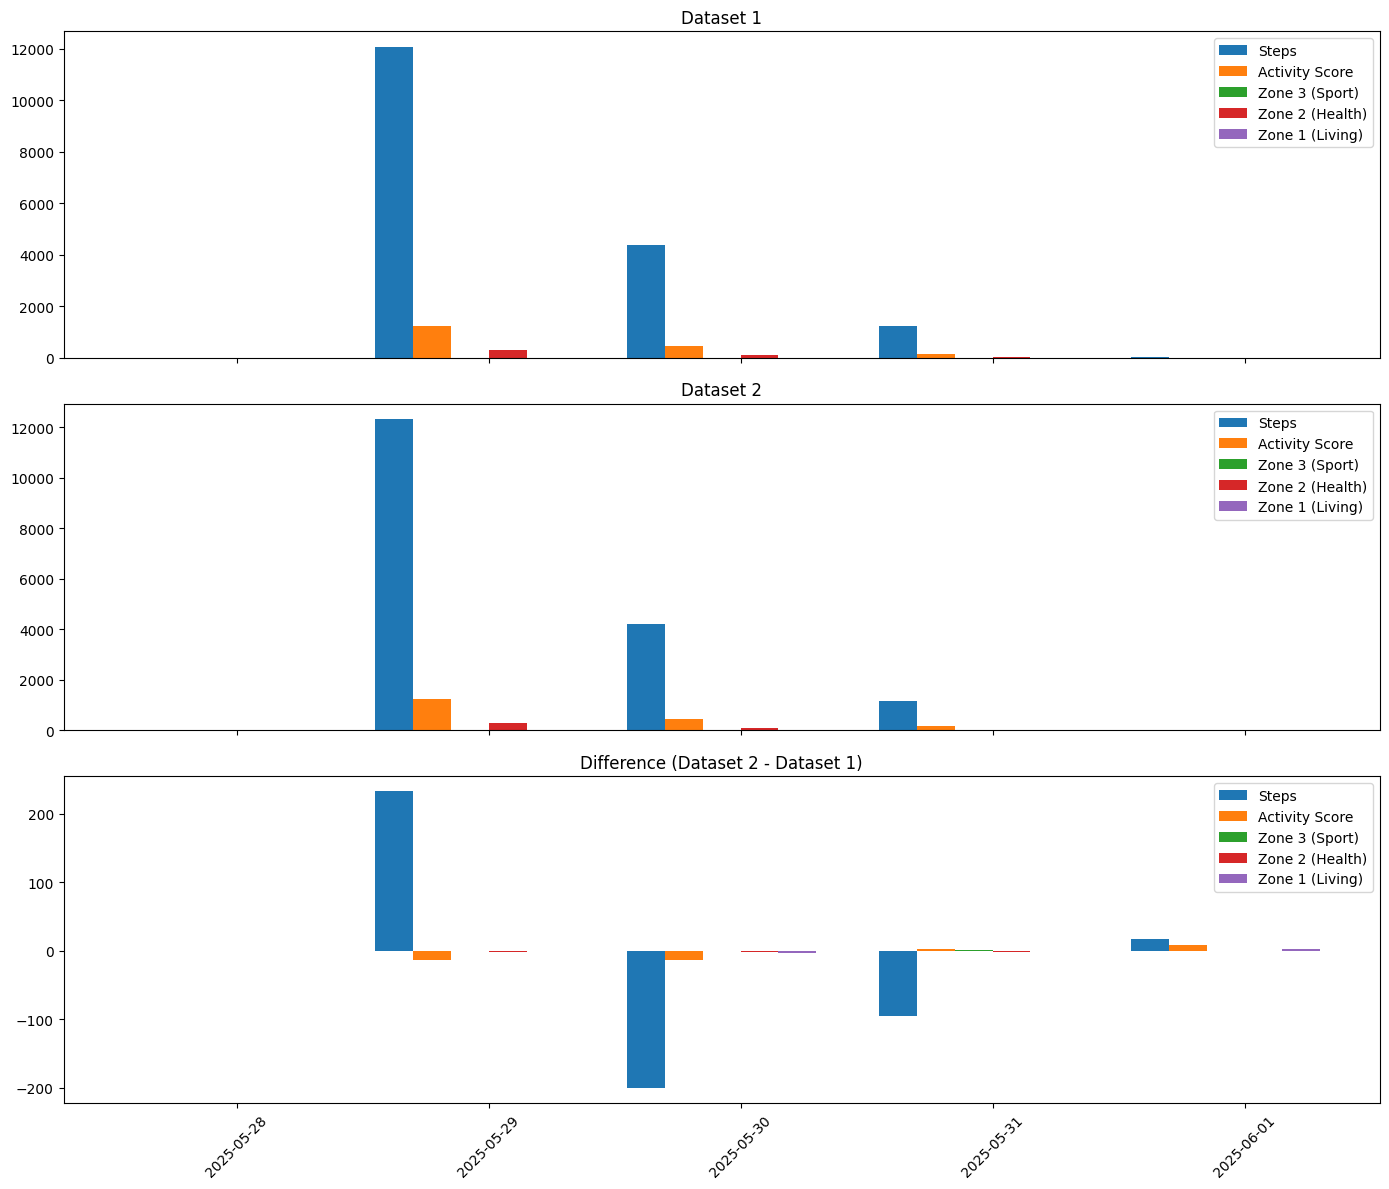

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSVs with BOM handling
df1 = pd.read_csv("./data/dayData_90242_3_experiment.csv", parse_dates=["Date"])
df2 = pd.read_csv("./data/dayData_90248_3_experiment.csv ", parse_dates=["Date"])

# Parse dates and set index
df1["Date"] = pd.to_datetime(df1["Date"])
df2["Date"] = pd.to_datetime(df2["Date"])
df1.set_index("Date", inplace=True)
df2.set_index("Date", inplace=True)

# Metrics
metrics = ["Steps", "Activity Score", "Zone 3 (Sport)", "Zone 2 (Health)", "Zone 1 (Living)"]
dates = df1.index.strftime("%Y-%m-%d")
x = np.arange(len(dates))
width = 0.15  # smaller width for multiple bars per group

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot Dataset 1
for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, df1[metric], width, label=metric)
axes[0].set_title("Dataset 1")
axes[0].legend()

# Plot Dataset 2
for i, metric in enumerate(metrics):
    axes[1].bar(x + i * width, df2[metric], width, label=metric)
axes[1].set_title("Dataset 2")
axes[1].legend()

# Plot Difference
diff = df2[metrics] - df1[metrics]
for i, metric in enumerate(metrics):
    axes[2].bar(x + i * width, diff[metric], width, label=metric)
axes[2].set_title("Difference (Dataset 2 - Dataset 1)")
axes[2].legend()

# X-axis labels
plt.xticks(ticks=x + (width * len(metrics) / 2), labels=dates, rotation=45)
plt.tight_layout()
plt.show()
